Agregando valores por grande area, area e subarea, pra verificar se são fortes para a predicao

In [2]:
import duckdb

con = duckdb.connect()
agg_df = con.execute("""
SELECT
    grande_area,
    area,
    subarea,
    SUM(valor_pago) AS valor_pago_total
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY grande_area, area, subarea
ORDER BY valor_pago_total DESC
""").fetchdf()

agg_df.head(50)

,grande_area,area,subarea,valor_pago_total
0,Ciências da Saúde,Medicina,Clínica Médica,1.801190e+09
1,Ciências Biológicas,Biotecnologia,Biotecnologia Ambiental e Recursos Naturais,1.650046e+09
2,Ciências Exatas e da Terra,Química,Química Analítica,1.546927e+09
3,Ciências Biológicas,Ecologia,Ecologia Aplicada,1.094217e+09
4,Ciências da Saúde,Saúde Coletiva,Saúde Pública,9.521982e+08
5,Ciências Exatas e da Terra,Ciências Ambientais,Não informado,9.389794e+08
6,Ciências Biológicas,Biotecnologia,Biotecnologia em Saúde Humana e Animal,8.685582e+08
7,Ciências Agrárias,Agronomia,Fitotecnia,7.157867e+08
8,Ciências Exatas e da Terra,Física,Física da Matéria Condensada,7.087735e+08
9,Ciências Exatas e da Terra,Química,Química Orgânica,6.830287e+08


As grandes areas da saúde, biologicas e engenharias são as que mais recebem fomento no cnpq. -> tentar ligar com tipo_modalidade, já que ajuda muito na predicao

1. foi feito uma visualizacao hierarquica dos valores por area, grande area e subarea

In [3]:
import plotly.express as px

treemap_df = con.execute("""
SELECT
    grande_area,
    area,
    subarea,
    SUM(valor_pago) AS valor_pago_total
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY grande_area, area, subarea
""").fetchdf()

treemap_df[['grande_area','area','subarea']] = treemap_df[['grande_area','area','subarea']].fillna('Unknown')

fig = px.treemap(
    treemap_df,
    path=['grande_area', 'area', 'subarea'],
    values='valor_pago_total',
    color='valor_pago_total',
    color_continuous_scale='Blues',
    title='Treemap do Fomento por Grande Área / Área / Subárea'
)

fig.show()

analisando fomento por grande area e tipo de modalidade

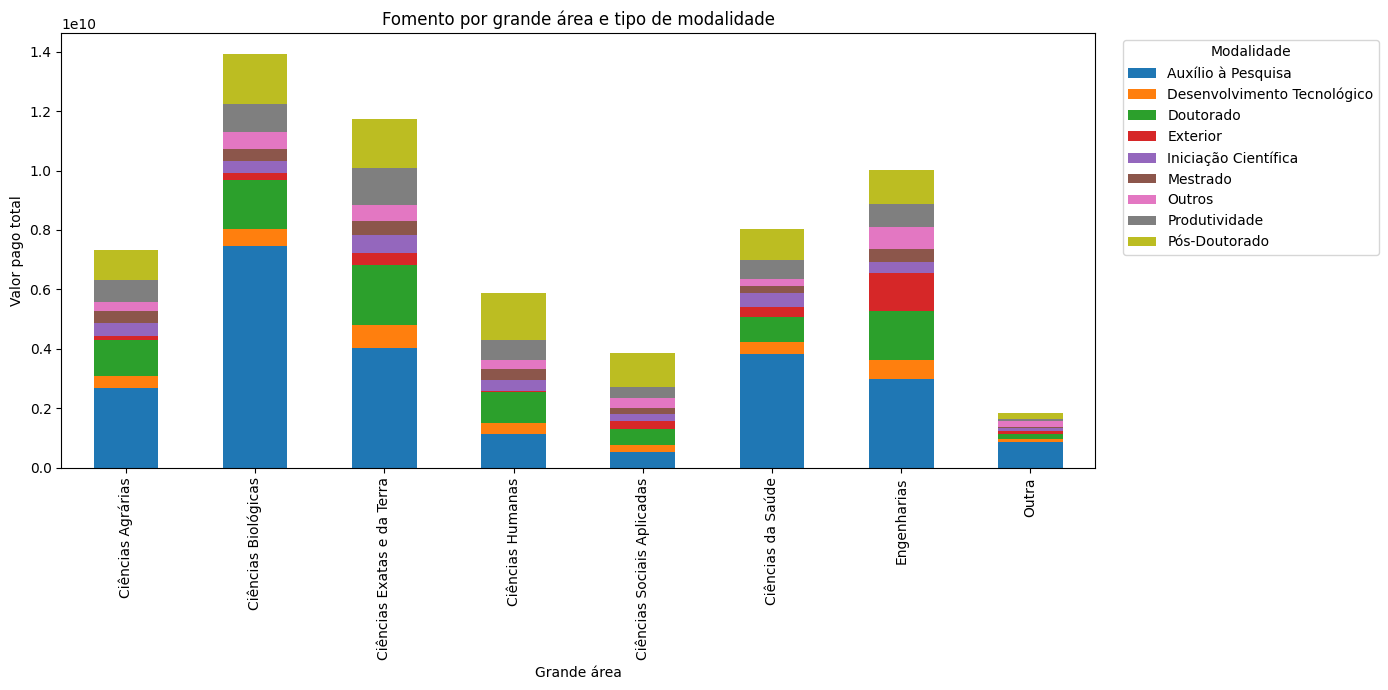

In [4]:
import pandas as pd

import matplotlib.pyplot as plt

modalidade_df = con.execute("""
SELECT
    grande_area,
    tipo_modalidade,
    SUM(valor_pago) AS valor_pago_total
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY grande_area, tipo_modalidade
ORDER BY valor_pago_total DESC
""").fetchdf()



top_areas = modalidade_df.groupby('grande_area')['valor_pago_total'].sum().nlargest(8).index
plot_df = modalidade_df[modalidade_df['grande_area'].isin(top_areas)].pivot_table(
    index='grande_area',
    columns='tipo_modalidade',
    values='valor_pago_total',
    aggfunc='sum',
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(14, 7))

plot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title('Fomento por grande área e tipo de modalidade')
ax.set_xlabel('Grande área')
ax.set_ylabel('Valor pago total')

ax.legend(
    title='Modalidade',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Usando correlacao entre as variaveis, pra analisar grande area -> tipo da modalidade

In [5]:
# Matriz de confusão 
conf_df = con.execute("""
SELECT
    COALESCE(grande_area, 'Unknown') AS grande_area,
    COALESCE(tipo_modalidade, 'Unknown') AS tipo_modalidade,
    COUNT(*) AS qtd
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY 1, 2
""").fetchdf()

conf_matrix = conf_df.pivot(
    index='grande_area',
    columns='tipo_modalidade',
    values='qtd'
).fillna(0)

conf_matrix_norm = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

fig = px.imshow(
    conf_matrix_norm,
    text_auto='.1%',
    aspect='auto',
    color_continuous_scale='Blues',
    title='Matriz de confusão normalizada: grande_area x tipo_modalidade'
)

fig.update_layout(
    xaxis_title='Tipo de modalidade',
    yaxis_title='Grande área'
)

fig.show()

explorando programa_cnpq

In [6]:
programa_df = con.execute("""
SELECT
    COALESCE(programa_cnpq, 'Unknown') AS programa_cnpq,
    SUM(valor_pago) AS valor_pago_total,
    COUNT(*) AS qtd
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY programa_cnpq
ORDER BY valor_pago_total DESC
""").fetchdf()

programa_df.head(50)

,programa_cnpq,valor_pago_total,qtd
0,PROGRAMA ESPECIAL DE COOPERACAO INTERNACIONAL/...,1.208133e+10,6674
1,Programa de Tecnologias Ambientais,8.333380e+09,2288
2,PROGRAMA DE POS GRADUAÇÃO,5.612484e+09,427981
3,Programa Regular de Apoio a Projetos de Pesquisa,3.461420e+09,18978
4,Programa Ciência sem Fronteiras,2.586998e+09,53759
5,Programa Institutos Nacionais de Ciência e Tec...,2.258618e+09,40794
6,Programa Institucional de Bolsas de Iniciação ...,2.169477e+09,979166
7,Programa Institucional de Bolsas de Pós-Gradua...,2.047658e+09,77663
8,Programa Especial de Cooperação com o Ministér...,1.909520e+09,7617
9,PROGRAMA DE CIENCIA E TECNOLOGIA DA SAUDE - CT...,1.704277e+09,7588


analisando a reagiao destino -> existe alguma regiao com viés?

In [7]:

regiao_df = con.execute("""
SELECT
    COALESCE(regiao_destino, 'Não informado') AS regiao_destino,
    SUM(valor_pago) AS valor_pago_total,
    COUNT(*) AS qtd
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY regiao_destino
ORDER BY valor_pago_total DESC
""").fetchdf()

regiao_df.head(50)

# plot simples
import plotly.express as px

fig = px.bar(
    regiao_df.sort_values('valor_pago_total', ascending=False),
    x='regiao_destino',
    y='valor_pago_total',
    title='Valor pago por região de destino',
    labels={'regiao_destino': 'Região destino', 'valor_pago_total': 'Valor pago (R$)'}
)
fig.update_layout(xaxis_tickangle=45, yaxis_tickformat=",")
fig.show()

A maioria é Não informado, pela formatacao recente dos dados abertos

analisando o fomento distribuido por linha de fomento

In [8]:
# Usando LLM para analisar a distribuição por linha de fomento, já que tem muitos valores únicos
linha_fomento_df = con.execute("""
WITH base AS (
    SELECT
        COALESCE(linha_de_fomento, 'Não informado') AS linha_de_fomento,
        valor_pago
    FROM 'dados/cnpq_com_capes.parquet'
),
agg AS (
    SELECT
        linha_de_fomento,
        COUNT(*) AS qtd,
        SUM(valor_pago) AS valor_pago_total,
        AVG(valor_pago) AS valor_pago_medio
    FROM base
    GROUP BY 1
)
SELECT
    linha_de_fomento,
    qtd,
    valor_pago_total,
    valor_pago_medio,
    valor_pago_total / SUM(valor_pago_total) OVER () AS pct_total
FROM agg
ORDER BY valor_pago_total DESC
""").fetchdf()

linha_fomento_df.head(30)

,linha_de_fomento,qtd,valor_pago_total,valor_pago_medio,pct_total
0,APOIO A PROJETOS DE PESQUISA,170062,2.211727e+10,1.300542e+05,0.342026
1,APOIO A COOPERAÇÃO INTERNACIONAL,5919,1.182215e+10,1.997323e+06,0.182820
2,Apoio a Projetos de Pesquisas,109395,5.522590e+09,5.048302e+04,0.085402
3,Bolsas de Doutorado,267238,5.113028e+09,1.916528e+04,0.079069
4,Bolsas de Produtividade em Pesquisa e Tecnologia,340992,4.728457e+09,1.386677e+04,0.073122
5,BOLSAS DE FORMAÇÃO E DE PESQUISADORES,397790,2.786908e+09,7.005977e+03,0.043097
6,Bolsas de Graduação,54272,2.602403e+09,4.795111e+04,0.040244
7,Bolsas de Mestrado,273216,2.380910e+09,8.714386e+03,0.036819
8,Bolsas de Iniciação Científica,879687,1.713528e+09,1.947884e+03,0.026498
9,Bolsas de Pós-doutorado,50477,1.505679e+09,2.989297e+04,0.023284


In [ ]:
# Matriz de correlação entre UO (Unidade Organizacional) e Modalidade
uo_modalidade_df = con.execute("""
SELECT
    COALESCE(uo, 'Unknown') AS uo,
    COALESCE(tipo_modalidade, 'Unknown') AS tipo_modalidade,
    COUNT(*) AS qtd
FROM 'dados/cnpq_com_capes.parquet'
GROUP BY 1, 2
""").fetchdf()

uo_modalidade_matrix = uo_modalidade_df.pivot(
    index='uo',
    columns='tipo_modalidade',
    values='qtd'
).fillna(0)

uo_modalidade_matrix_norm = uo_modalidade_matrix.div(uo_modalidade_matrix.sum(axis=1), axis=0)

fig = px.imshow(
    uo_modalidade_matrix_norm,
    text_auto='.01%',
    aspect='auto',
    color_continuous_scale='Blues',
    title='Matriz de correlação normalizada: UO x Tipo de Modalidade',

)

fig.update_layout(
    xaxis_title='Tipo de Modalidade',
    yaxis_title='UO (Unidade Organizacional)',
    height=1200
)

fig.show()